# 5.2.1 用期望与方差描述随机量

## 学习目标与先修知识

能从离散分布（distribution）推导期望（expectation）与方差（variance），区分描述性方差与总体估计；解释高斯误差、标准差（standard deviation）和均值波动的单位。

先修：第 5.1 章的分布与重复；求和、平方和积分。 [复习上一节](../01-从重复实验建立概率/02-把抽样变成可比较的重复实验.ipynb)。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

释放量可能为 0 或 2 U；期望为 0.5 U 并不是某次必须释放的量。如何同时描述中心与波动，又不把“均值稳定”误当成“每次不变”？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN, GRAY = '#008bfb', '#ff0051', '#009e73', '#555555'

## 初步实验

In [2]:
values=np.array([0.,2.]);probabilities=np.array([.75,.25])
mean=float(values@probabilities)
display(Markdown(show_table(['量','数值'],[['期望 / U',mean],['中心平方平均 / U²',float(((values-mean)**2)@probabilities)]])))

| 量 | 数值 |
| --- | --- |
| 期望 / U | 0.5 |
| 中心平方平均 / U² | 0.75 |

## 模型假设

离散释放模型（model）按概率（probability）表独立抽取。另用高斯分布（Gaussian distribution）描述相对理想读数的误差，均值 0 U、标准差 σ=0.2 U；正负误差分别表示读数高于或低于理想值。比较每次 n=10、100 个误差的平均，各做 B=200 次独立重复，随机种子（random seed）为 5201。

## 数学解释与推导

离散期望是概率加权平均，$\mu=E[X]=\sum_x xp(x)$；方差是围绕期望的平方距离平均：
$$\operatorname{Var}(X)=E[(X-\mu)^2]=E[X^2]-\mu^2.$$
最后一步由展开平方并用 E[X]=μ 得到。标准差为方差平方根，与 X 单位相同；方差单位是平方单位。线性变换 Y=aX+b 有 E[Y]=aμ+b、Var(Y)=a²Var(X)，平移不改变散布。

对固定数组（array），描述性方差 $s_n^2=\sum_i(x_i-\bar x)^2/n$ 是这组数据的中心平方平均。若 n≥2 个样本独立同分布（independent and identically distributed）、方差有限，用它估计总体方差会偏小：$\sum(X_i-\bar X)^2=\sum X_i^2-n\bar X^2$，取期望并利用 Var($\bar X$)=σ²/n，得到 E[$s_n^2$]=(n−1)σ²/n。因此分母 n−1 的样本方差是无偏估计；n=1 时这种估计未定义。两种分母分别服务于描述现有数据和估计总体方差。

高斯分布（Gaussian distribution），又称正态分布（normal distribution），密度为
$$f(x)=\frac{1}{\sigma\sqrt{2\pi}}\exp\left[-\frac{(x-\mu)^2}{2\sigma^2}\right],\quad\sigma>0.$$
它对称、有无限支持；μ 为期望，σ² 为方差。可以通过积分面积和抽样检查它的形状与归一化。σ=0 时是确定值，不能代入该密度公式。

独立同分布平均的方差为 σ²/n：将 $(\sum_i(X_i-\mu))^2$ 展开，交叉项期望因独立且零均值消失，只剩 nσ²，再除以 n²。标准差因而缩为 σ/√n。依赖样本一般还会留下交叉项。

## 核心实现

把公式中的量和顺序写成可检查的计算。

In [3]:
def discrete_moments(values, probabilities):
    mean = sum(x*p for x,p in zip(values, probabilities))
    variance = sum(p*(x-mean)**2 for x,p in zip(values, probabilities))
    return mean, variance

## 对照实验

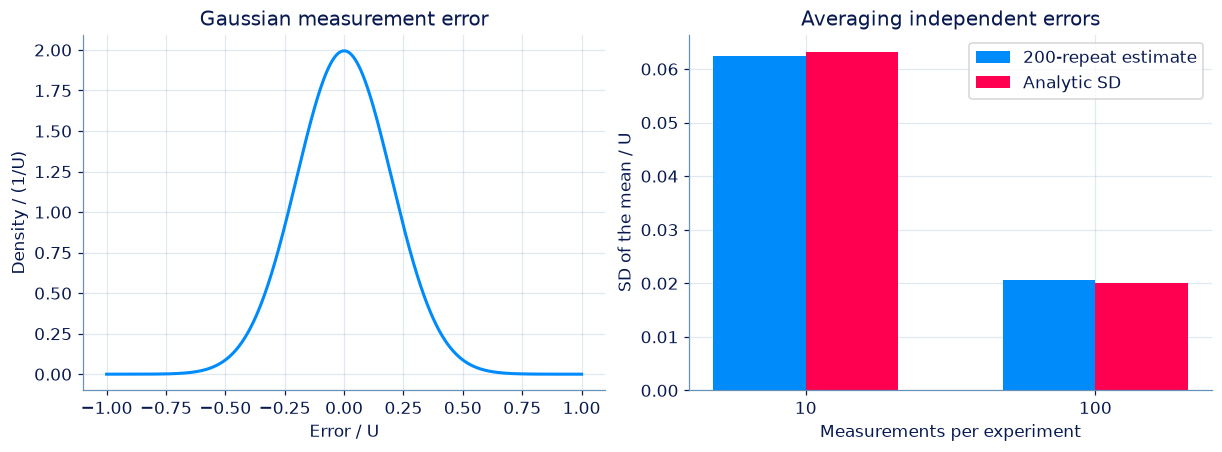

| n | 均值的样本方差 / U² | 理论方差 / U² | 平均值的 Monte Carlo 标准误 / U |
| --- | --- | --- | --- |
| 10 | 0.00390798 | 0.004 | 0.00447214 |
| 100 | 0.000425453 | 0.0004 | 0.00141421 |

根种子 5201 ；B= 200 ；PCG64；NumPy 2.5.3


In [4]:
sizes=[10,100];repeats=200;sigma=.2;root_seed=5201
streams=np.random.SeedSequence(root_seed).spawn(400)
means=[np.array([np.random.Generator(np.random.PCG64(streams[j*repeats+b])).normal(0,sigma,n).mean() for b in range(repeats)]) for j,n in enumerate(sizes)]
fig,axes=plt.subplots(1,2,figsize=(11,4))
grid=np.linspace(-1,1,4001);pdf=np.exp(-grid**2/(2*sigma**2))/(sigma*np.sqrt(2*np.pi))
axes[0].plot(grid,pdf,color=BLUE);axes[0].set(xlabel='Error / U',ylabel='Density / (1/U)',title='Gaussian measurement error')
axes[1].bar(np.arange(2)-.16,[v.std(ddof=1) for v in means],width=.32,color=BLUE,label='200-repeat estimate')
axes[1].bar(np.arange(2)+.16,[sigma/np.sqrt(n) for n in sizes],width=.32,color=PINK,label='Analytic SD')
axes[1].set(xticks=[0,1],xticklabels=sizes,xlabel='Measurements per experiment',ylabel='SD of the mean / U',title='Averaging independent errors');axes[1].legend()
plt.show()
display(Markdown(show_table(['n','均值的样本方差 / U²','理论方差 / U²','平均值的 Monte Carlo 标准误 / U'],[(n,v.var(ddof=1),sigma**2/n,sigma/np.sqrt(n*repeats)) for n,v in zip(sizes,means)])))
print('根种子',root_seed,'；B=',repeats,'；PCG64；NumPy',np.__version__)

## 结果解释

均值的散布与原始单次误差的散布是不同对象。这里标准误（standard error）是 200 次实验均值再平均后的随机误差尺度 σ/√(nB)，不是状态（state）路径的分位带。增加独立重复次数，可以减小平均结果的抽样波动。

### 独立核对

离散题用独立手算；高斯样本均值的解析分布给出检查尺度。五个标准误阈值用于程序诊断，不等同于绝不误报的数学定理。

In [5]:
np.testing.assert_allclose(discrete_moments([0,2],[.75,.25]),[.5,.75])
assert abs(np.trapezoid(pdf,grid)-1)<1e-6  # integration on ±5 sigma
for n,v in zip(sizes,means):
    expected=sigma**2/n
    assert abs(v.mean())<5*np.sqrt(expected/repeats)
    # Gaussian sample-variance SD, used as a generous diagnostic threshold.
    assert abs(v.var(ddof=1)-expected)<5*expected*np.sqrt(2/(repeats-1))
print('离散手算、密度积分和重复均值的解析矩核对通过。')

离散手算、密度积分和重复均值的解析矩核对通过。


[观察本章的动态可视化](http://127.0.0.1:8000/chapters/05-02-期望、方差、协方差与噪声/explore/)：改变一个条件，比较实现、分布与理论参照，再返回完整推导。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：从概率表计算位置与散布

理想细胞释放量只取给定离散值。计算其理论期望（expectation）和方差（variance），不把概率（probability）表当作等权样本。

**函数与代码模板**

```python
def solve(
    values: list[float],
    probabilities: list[float],
) -> tuple[float, float]:
    # 依据题目规则计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `values` | `list[float]` | 可能的释放量。 | U |
| `probabilities` | `list[float]` | 与释放量一一对应的概率。 | 1 |

**返回值**

按以下顺序返回元组：(mean, variance)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `mean` | `float` | 理论期望。 | U |
| `variance` | `float` | 理论方差。 | U² |

**计算规则**

mean=Σpᵢxᵢ；variance=Σpᵢ(xᵢ−mean)²。

**约束与边界**

- 所有数值有限；不修改输入（input）列表。
- 相同长度 1—30；−10≤values[i]≤10；概率非负且和为 1（浮点误差≤1e−12）。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| values | 可能的释放量。 | [0, 2] | U |
| probabilities | 与释放量一一对应的概率。 | [0.75, 0.25] | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
values = [0, 2]
probabilities = [0.75, 0.25]

result = solve(values, probabilities)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| mean | 理论期望。 | 0.5 | U |
| variance | 理论方差。 | 0.75 | U² |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (0.5, 0.75)
```

**样例解释**

期望 0.5 U；方差为 0.75×0.5²+0.25×1.5²=0.75 U²。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：从概率表计算位置与散布](http://127.0.0.1:8000/chapters/05-02-%E6%9C%9F%E6%9C%9B%E3%80%81%E6%96%B9%E5%B7%AE%E3%80%81%E5%8D%8F%E6%96%B9%E5%B7%AE%E4%B8%8E%E5%99%AA%E5%A3%B0/practice/?question=p05-moments)

### 第 2 题 · 多项选择题：换单位后哪些量会改变

X 的单位为 U，E[X]=2 U，Var(X)=3 U²。令 Y=10X+5，Y 的数值使用相应的新标度。哪些数值正确？

- **A.** Var(Y)=35。
- **B.** Var(Y)=300。
- **C.** 标准差（standard deviation）变为原数值的 10 倍。
- **D.** E[Y]=25。

[作答：换单位后哪些量会改变](http://127.0.0.1:8000/chapters/05-02-%E6%9C%9F%E6%9C%9B%E3%80%81%E6%96%B9%E5%B7%AE%E3%80%81%E5%8D%8F%E6%96%B9%E5%B7%AE%E4%B8%8E%E5%99%AA%E5%A3%B0/practice/?question=p05-variance-units)

### 第 3 题 · 单项选择题：高斯误差为什么能为负

测量值等于理想读数加零均值高斯误差。误差标准差（standard deviation）为 0.2 U。哪项正确？

- **A.** 方差（variance）为 0.2 U。
- **B.** 零均值意味着每次误差都为零。
- **C.** 高斯误差绝不超出 ±0.6 U。
- **D.** 负误差表示读数低于理想值，并不意味着负所追踪物质总量（tracked amount）。

[作答：高斯误差为什么能为负](http://127.0.0.1:8000/chapters/05-02-%E6%9C%9F%E6%9C%9B%E3%80%81%E6%96%B9%E5%B7%AE%E3%80%81%E5%8D%8F%E6%96%B9%E5%B7%AE%E4%B8%8E%E5%99%AA%E5%A3%B0/practice/?question=p05-gaussian-domain)

### 第 4 题 · 单项选择题：两个方差分母的区别

固定数组（array） [0,2] 的描述性中心平方偏差用分母 n；若作为独立同分布（independent and identically distributed）样本估计总体方差（variance），用分母 n−1。两者依次是多少？

- **A.** 0 和 2。
- **B.** 1 和 2。
- **C.** 2 和 1。
- **D.** 1 和 1。

[作答：两个方差分母的区别](http://127.0.0.1:8000/chapters/05-02-%E6%9C%9F%E6%9C%9B%E3%80%81%E6%96%B9%E5%B7%AE%E3%80%81%E5%8D%8F%E6%96%B9%E5%B7%AE%E4%B8%8E%E5%99%AA%E5%A3%B0/practice/?question=p05-sample-denominator)

**进一步阅读**

[MIT 6.041 讲义](https://ocw.mit.edu/courses/6-041-probabilistic-systems-analysis-and-applied-probability-fall-2010/pages/lecture-notes/)：第 5—8、19—20 讲：期望、方差、连续变量与均值极限。